# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika | 5054251050|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [106]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

random_state = 42

In [65]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [66]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
# Menampilkan ukuran dataset
df.info()

# 1. Menampilkan ukuran dataset (jumlah baris dan kolom)
print(f"Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")

# 3. Jumlah missing value
print("\nJumlah missing value")
print(df.isnull().sum())

# 4. Menghitung jumlah missing value berbentuk '?' (terutama kolom stalk-root)
missing_q = (df == '?').sum()

print("\nJumlah Missing Value ('?') per Kolom")
print(missing_q[missing_q > 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [67]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
# Menampilkan jumlah nilai unik setiap kolom
unique_values = df.nunique()
display(unique_values.to_frame(name="Jumlah Nilai Unik"))

,Jumlah Nilai Unik
class,2
cap-shape,6
cap-surface,4
cap-color,10
bruises,2
odor,9
gill-attachment,2
gill-spacing,2
gill-size,2
gill-color,12


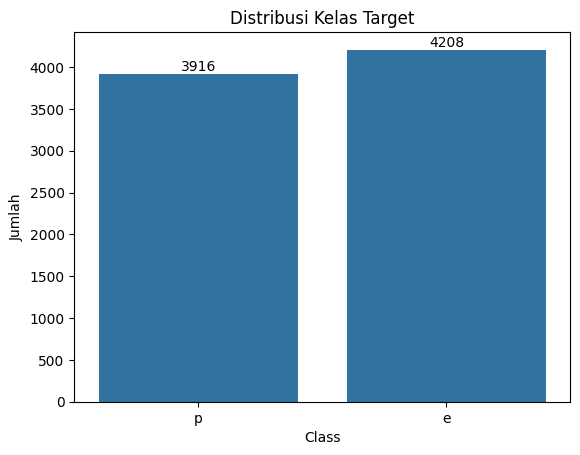

In [68]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
ax = sns.countplot(data=df, x='class')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribusi Kelas Target')
plt.xlabel('Class')
plt.ylabel('Jumlah')

plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [69]:
# Cek duplikat baris
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


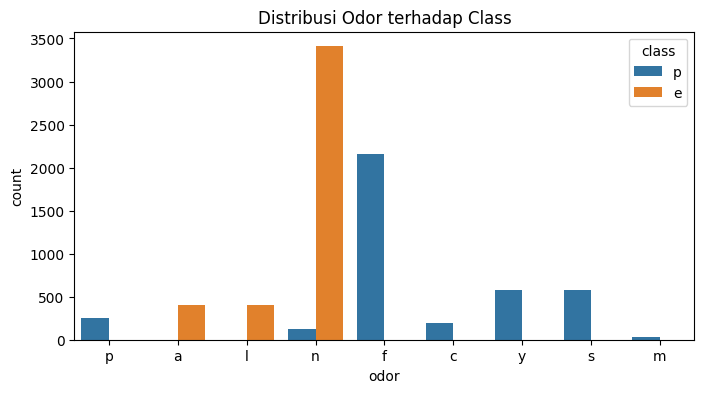

In [70]:
# Hubungan odor vs class (odor dikenal sebagai fitur paling diskriminatif)
plt.figure(figsize=(8, 4))
sns.countplot(x='odor', hue='class', data=df)
plt.title('Distribusi Odor terhadap Class')
plt.show()

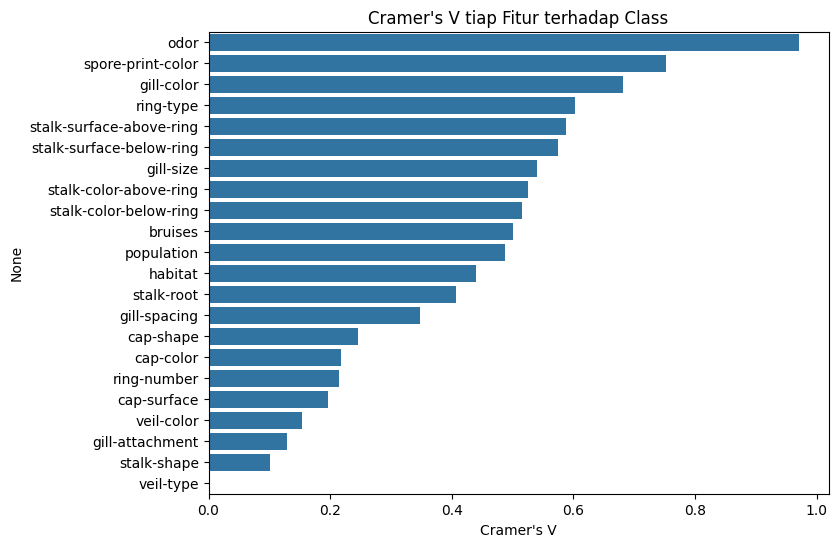

In [71]:
# Kekuatan asosiasi tiap fitur kategorikal terhadap target, pakai Cramer's V
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    ct = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    if min(r, k) <= 1:
        return 0.0
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

feature_cols = [c for c in df.columns if c != 'class']
assoc = {col: cramers_v(df[col], df['class']) for col in feature_cols}
assoc_df = pd.Series(assoc).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=assoc_df.values, y=assoc_df.index)
plt.title("Cramer's V tiap Fitur terhadap Class")
plt.xlabel("Cramer's V")
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [72]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
# Ukuran dataset sebelum preprocessing
print("Ukuran dataset sebelum preprocessing:", df.shape)

# Cek jumlah '?' pada stalk-root
print("Jumlah '?' sebelum preprocessing:",
      (df['stalk-root'] == '?').sum())

# Cari modus dari nilai stalk-root yang bukan '?'
modus = df.loc[df['stalk-root'] != '?', 'stalk-root'].mode()[0]

# Ganti '?' dengan nilai modus
df['stalk-root'] = df['stalk-root'].replace('?', modus)

# Cek hasil preprocessing
print("Modus stalk-root:", modus)
print("Jumlah '?' setelah preprocessing:",
      (df['stalk-root'] == '?').sum())
print("Ukuran dataset setelah preprocessing:", df.shape)

Ukuran dataset sebelum preprocessing: (8124, 23)
Jumlah '?' sebelum preprocessing: 2480
Modus stalk-root: b
Jumlah '?' setelah preprocessing: 0
Ukuran dataset setelah preprocessing: (8124, 23)


In [73]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Fitur dengan hanya 1 nilai unik:", single_value_cols)

df = df.drop(columns=single_value_cols)
print("Kolom tersisa:", df.shape[1])

Fitur dengan hanya 1 nilai unik: ['veil-type']
Kolom tersisa: 22


In [74]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nDistribusi train:\n", y_train.value_counts(normalize=True))
print("\nDistribusi test:\n", y_test.value_counts(normalize=True))

Train shape: (6499, 21) Test shape: (1625, 21)

Distribusi train:
 class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Distribusi test:
 class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


In [75]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = ordinal_encoder.fit_transform(X_train)
X_test_ord = ordinal_encoder.transform(X_test)

X_train_ord = X_train_ord.astype(int)
X_test_ord = X_test_ord.astype(int)

X_train_ord[:5]

array([[ 2,  3,  9,  0,  2,  1,  0,  0,  2,  0,  0,  1,  1,  6,  0,  2,
         1,  2,  1,  5,  1],
       [ 5,  2,  5,  1,  5,  1,  0,  0,  1,  0,  0,  2,  2,  2,  7,  2,
         2,  0,  7,  1,  6],
       [ 0,  2,  3,  0,  5,  1,  1,  0, 10,  0,  0,  1,  2,  7,  7,  2,
         2,  4,  7,  3,  1],
       [ 2,  2,  4,  0,  7,  1,  0,  1,  0,  1,  0,  1,  1,  6,  7,  2,
         1,  0,  7,  4,  0],
       [ 3,  3,  4,  0,  2,  1,  0,  1,  0,  1,  0,  2,  1,  6,  6,  2,
         1,  0,  7,  4,  4]])

In [76]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
X_train_ohe = onehot_encoder.fit_transform(X_train)
X_test_ohe = onehot_encoder.transform(X_test)

print("Shape train hasil OneHotEncoder:", X_train_ohe.shape)
print("Shape test hasil OneHotEncoder:", X_test_ohe.shape)

Shape train hasil OneHotEncoder: (6499, 115)
Shape test hasil OneHotEncoder: (1625, 115)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [90]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
model_cnb = CategoricalNB()
model_cnb.fit(X_train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [92]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cnb = model_cnb.predict(X_test_ord)
y_proba_cnb = model_cnb.predict_proba(X_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [96]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
model_bnb = BernoulliNB()
model_bnb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 115)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 115)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [97]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = model_bnb.predict(X_test_ohe)
y_proba_bnb = model_bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [99]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
model_mnb = MultinomialNB()
model_mnb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 115)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 115)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,115


In [100]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = model_mnb.predict(X_test_ohe)
y_proba_mnb = model_mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [105]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Hitung metrik untuk setiap model
results = {
    'Model': ['CategoricalNB', 'BernoulliNB', 'MultinomialNB'],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_cnb),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_mnb)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_cnb, pos_label=1),
        precision_score(y_test, y_pred_bnb, pos_label=1),
        precision_score(y_test, y_pred_mnb, pos_label=1)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_cnb, pos_label=1),
        recall_score(y_test, y_pred_bnb, pos_label=1),
        recall_score(y_test, y_pred_mnb, pos_label=1)
    ],
    
    'F1-Score': [
        f1_score(y_test, y_pred_cnb, pos_label=1),
        f1_score(y_test, y_pred_bnb, pos_label=1),
        f1_score(y_test, y_pred_mnb, pos_label=1)
    ]
}

# Buat tabel perbandingan
results_df = pd.DataFrame(results)

# Tampilkan hasil
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CategoricalNB,0.947077,0.988780,0.900383,0.942513
1,BernoulliNB,0.933538,0.982833,0.877395,0.927126
2,MultinomialNB,0.947077,0.988780,0.900383,0.942513


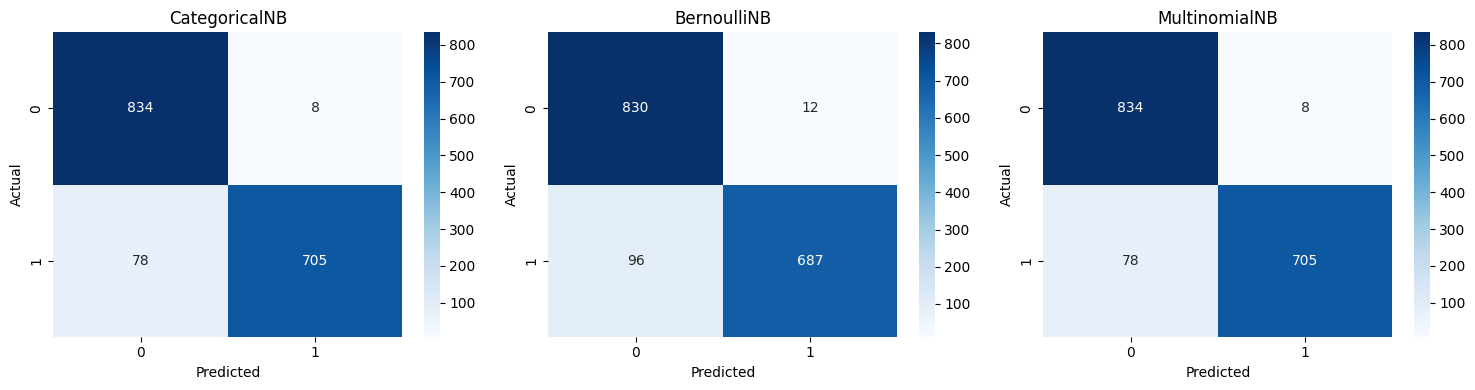

In [107]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
# Hitung confusion matrix
cm_cnb = confusion_matrix(y_test, y_pred_cnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
cm_mnb = confusion_matrix(y_test, y_pred_mnb)

# Buat subplot 1 baris, 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CategoricalNB
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('CategoricalNB')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# BernoulliNB
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('BernoulliNB')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# MultinomialNB
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('MultinomialNB')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

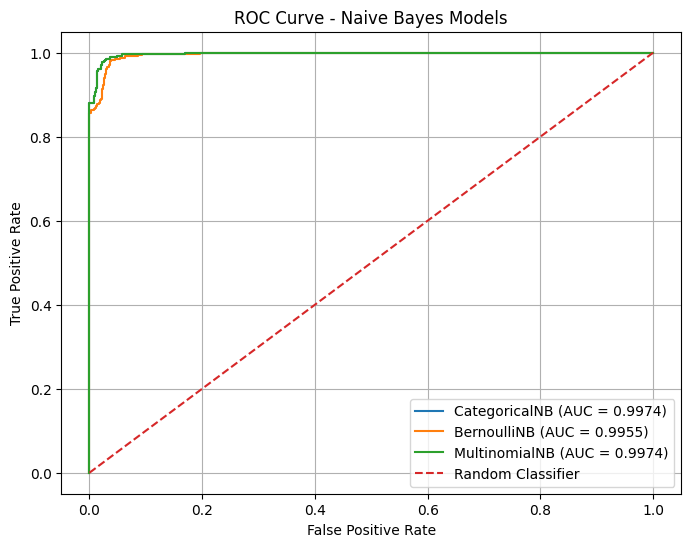

In [110]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_proba_cnb)
auc_cnb = roc_auc_score(y_test, y_proba_cnb)

fpr_bnb, tpr_bnb, _ = roc_curve(y_test, y_proba_bnb)
auc_bnb = roc_auc_score(y_test, y_proba_bnb)

fpr_mnb, tpr_mnb, _ = roc_curve(y_test, y_proba_mnb)
auc_mnb = roc_auc_score(y_test, y_proba_mnb)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr_cnb, tpr_cnb, label=f'CategoricalNB (AUC = {auc_cnb:.4f})')
plt.plot(fpr_bnb, tpr_bnb, label=f'BernoulliNB (AUC = {auc_bnb:.4f})')
plt.plot(fpr_mnb, tpr_mnb, label=f'MultinomialNB (AUC = {auc_mnb:.4f})')

# Garis random classifier
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes Models')
plt.legend()
plt.grid()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Dataset terdiri dari **8.124 data dan 23 kolom**, dengan `class` sebagai target dan 22 fitur bertipe kategorikal. Beberapa fitur yang digunakan antara lain `cap-shape`, `cap-color`, `odor`, `gill-color`, `stalk-root`, `ring-type`, `spore-print-color`, `population`, dan `habitat`.

Pada tahap preprocessing, ditemukan **2.480 nilai ****`?`**** pada ****`stalk-root`**. Nilai tersebut diganti menggunakan modus, yaitu `b`, sehingga seluruh data tetap dipertahankan tanpa menghapus baris maupun kolom.

| Model         | Accuracy | Precision | Recall | F1-Score |    AUC |
| ------------- | -------: | --------: | -----: | -------: | -----: |
| CategoricalNB |   0.9471 |    0.9888 | 0.9004 |   0.9425 | 0.9974 |
| BernoulliNB   |   0.9335 |    0.9828 | 0.8774 |   0.9271 | 0.9955 |
| MultinomialNB |   0.9471 |    0.9888 | 0.9004 |   0.9425 | 0.9974 |

**CategoricalNB** menggunakan `OrdinalEncoder` untuk mengubah kategori menjadi bilangan integer. Nilai tersebut diperlakukan sebagai kategori, bukan sebagai data numerik yang memiliki urutan.

**BernoulliNB** menggunakan `OneHotEncoder` sehingga setiap kategori direpresentasikan dalam bentuk biner 0/1. Model ini memiliki performa sedikit lebih rendah dibandingkan dua model lainnya, terutama pada **Recall (0.8774)**.

**MultinomialNB** juga menggunakan representasi One-Hot berupa nilai 0/1 yang bersifat non-negatif. Pada eksperimen ini, MultinomialNB menghasilkan metrik yang **identik dengan CategoricalNB**, yaitu Accuracy 0.9471, F1-Score 0.9425, dan AUC 0.9974.

Secara keseluruhan, ketiga model mampu melakukan klasifikasi dengan performa tinggi. Nilai precision yang mendekati 1 menunjukkan bahwa sebagian besar prediksi positif yang dihasilkan merupakan kelas positif yang benar. Sementara itu, nilai AUC yang sangat tinggi menunjukkan kemampuan model yang baik dalam membedakan kedua kelas pada berbagai threshold.

Perbedaan performa menunjukkan bahwa **cara representasi data kategorikal dan asumsi masing-masing model dapat memengaruhi hasil klasifikasi**. Pada dataset ini, CategoricalNB dan MultinomialNB menghasilkan metrik yang sama, sedangkan BernoulliNB memiliki performa sedikit lebih rendah.


# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

#### Kesimpulan
Berdasarkan eksperimen yang dilakukan, ketiga model Naive Bayes mampu mengklasifikasikan dataset Mushroom dengan performa yang tinggi. **CategoricalNB dan MultinomialNB menghasilkan metrik evaluasi yang identik**, dengan Accuracy sebesar **0.9471** dan AUC **0.9974**, sedangkan BernoulliNB memperoleh Accuracy **0.9335** dan AUC **0.9955**. Hal ini menunjukkan bahwa pemilihan representasi data kategorikal dapat memengaruhi performa model.

#### Saran
Untuk eksperimen selanjutnya, preprocessing dapat dikembangkan dengan mencoba metode penanganan missing value lain pada `stalk-root`, serta membandingkan hasil menggunakan beberapa pembagian data atau cross-validation. Selain itu, model Naive Bayes dapat dibandingkan dengan algoritma klasifikasi lain untuk melihat perbedaan performanya pada dataset yang sama.